In [ ]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import rcParams

import fluopy.emissions as em

%load_ext autoreload
%autoreload 2


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

reading_from_1 = r"D:\python_output\Chapter_I\1_11_multi_f_et_irradiance\OET"
reading_from_2 = r"D:\python_output\Chapter_I\1_11_multi_f_et_irradiance\noOET"
saving_to = r"D:\python_output\Chapter_I\1_11_multi_f_et_irradiance"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
fluopy.blinking version: 0.1.0
fluopy.emissions version: 0.1.0
fluopy.fcs version: 0.1.0
fluopy.fluorophores version: 0.1.0
fluopy.formulas version: 0.1.0
fluopy.simulation version: 0.1.0
fluopy.prediction version: 0.1.0
fluopy.analysis version: 0.1.0
fluopy.transitions version: 0.1.0
fluopy.routines version: 0.1.0


## Reading the data

In [3]:
df100_OET = pd.read_parquet(reading_from_1 + r"\irradiance100\emission_df.parquet")
df50_OET = pd.read_parquet(reading_from_1 + r"\irradiance50\emission_df.parquet")
df25_OET = pd.read_parquet(reading_from_1 + r"\irradiance25\emission_df.parquet")
df10_OET = pd.read_parquet(reading_from_1 + r"\irradiance10\emission_df.parquet")
df1_OET = pd.read_parquet(reading_from_1 + r"\irradiance1\emission_df.parquet")

df100_noOET = pd.read_parquet(reading_from_2 + r"\irradiance100\emission_df.parquet")
df50_noOET = pd.read_parquet(reading_from_2 + r"\irradiance50\emission_df.parquet")
df25_noOET = pd.read_parquet(reading_from_2 + r"\irradiance25\emission_df.parquet")
df10_noOET = pd.read_parquet(reading_from_2 + r"\irradiance10\emission_df.parquet")
df1_noOET = pd.read_parquet(reading_from_2 + r"\irradiance1\emission_df.parquet")

## Figure

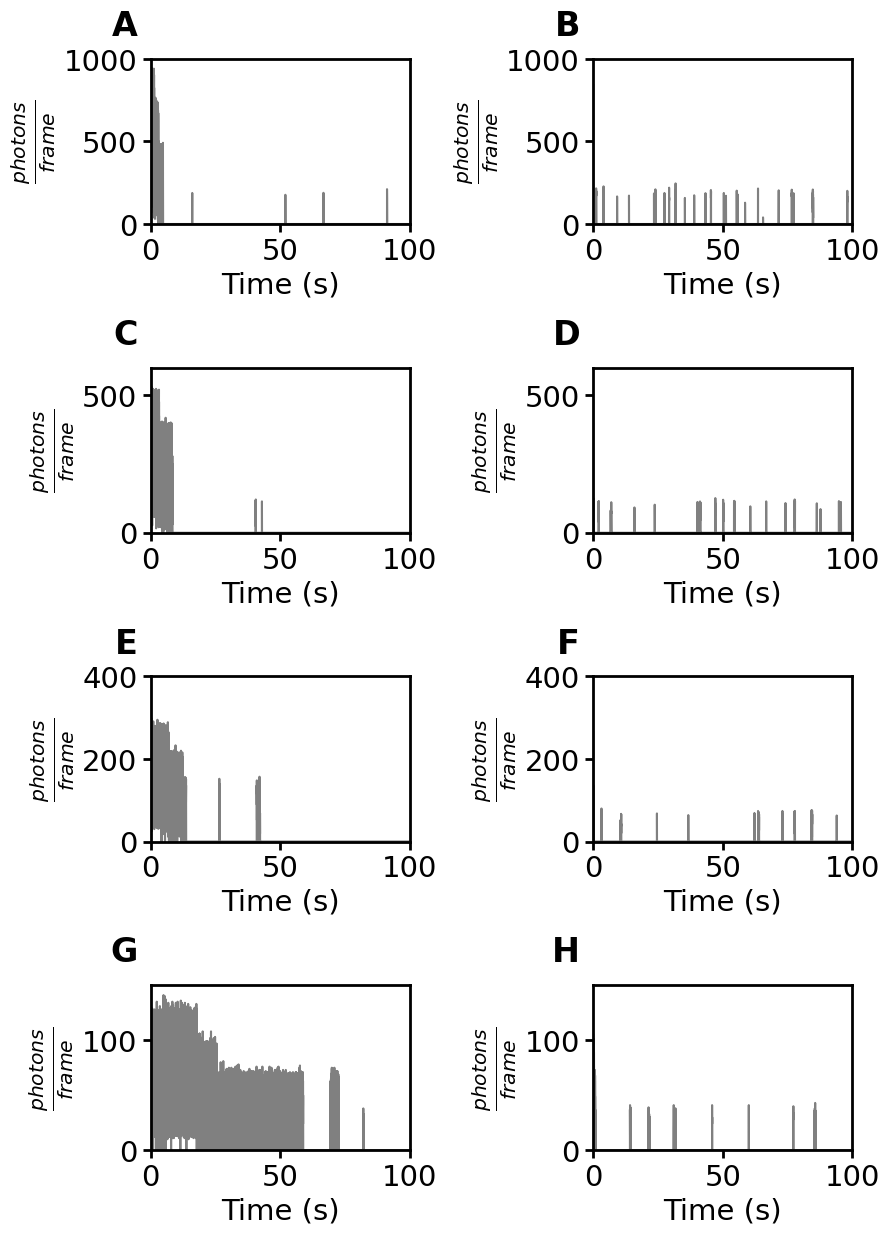

In [ ]:
rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(4, 2)
fig = plt.figure(figsize=(9, 12.5))
emis = em.Emissions()

ax1 = fig.add_subplot(gs[0, 0])
emis.event_time_series = df100_OET.iloc[:, 1]
emis.plot_time_series(xlim=[0, 100], ylim=[0, 1000], axes=ax1, color="grey")
ax2 = fig.add_subplot(gs[0, 1])
emis.event_time_series = df100_noOET.iloc[:, 0]
emis.plot_time_series(xlim=[0, 100], ylim=[0, 1000], axes=ax2, color="grey")

ax3 = fig.add_subplot(gs[1, 0])
emis.event_time_series = df50_OET.iloc[:, 3]
emis.plot_time_series(xlim=[0, 100], ylim=[0, 600], axes=ax3, color="grey")
ax4 = fig.add_subplot(gs[1, 1])
emis.event_time_series = df50_noOET.iloc[:, 0]
emis.plot_time_series(xlim=[0, 100], ylim=[0, 600], axes=ax4, color="grey")

ax5 = fig.add_subplot(gs[2, 0])
emis.event_time_series = df25_OET.iloc[:, 2]
emis.plot_time_series(xlim=[0, 100], ylim=[0, 400], axes=ax5, color="grey")
ax6 = fig.add_subplot(gs[2, 1])
emis.event_time_series = df25_noOET.iloc[:, 0]
emis.plot_time_series(xlim=[0, 100], ylim=[0, 400], axes=ax6, color="grey")

ax7 = fig.add_subplot(gs[3, 0])
emis.event_time_series = df10_OET.iloc[:, 2]
emis.plot_time_series(xlim=[0, 100], ylim=[0, 150], axes=ax7, color="grey")
ax8 = fig.add_subplot(gs[3, 1])
emis.event_time_series = df10_noOET.iloc[:, 0]
emis.plot_time_series(xlim=[0, 100], ylim=[0, 150], axes=ax8, color="grey")

axes = fig.get_axes()
for axis, letter in zip(axes, ["A", "B", "C", "D", "E", "F", "G", "H"]):
    offset = -0.05
    axis.text(
        offset,
        1.1,
        letter,
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="bottom",
        ha="right",
    )

fig.tight_layout()
fig.savefig(
    saving_to + r"\multi_f_et_irradiance.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.1,
)